# Sustainability comparison of generator experiments

This notebook estimates the computational burden of the generator workflows from the canonical
sustainability-event registry. It reports a hardware-specific time-to-energy conversion for the RTX
5060 Ti using $E = tP$ with $P = 0.170\,\mathrm{kW}$, because the recorded CodeCarbon energy field is
not reliable for this device. The analysis is canonical-only: failed, reused, very short, and exact
duplicate events are excluded by the registry policy, so it does not represent all electricity spent
during development. Classifier training is outside scope, and G06 is treated as a generation-pool
ablation that shares G05's model rather than as an independently trained generator.

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
import pandas as pd
import matplotlib.pyplot as plt
from sustainability_registry import load_events, deduplicate_canonical_events

POWER_KW = 0.170          # measured mean draw of the RTX 5060 Ti during real generation
MIN_SECONDS = 60          # keep only real runs, drop CodeCarbon empty-restart appends
POOL = 1361               # canonical synthetic pool per generator
FIGURES = ROOT / 'results/5_sustainability/figures'; FIGURES.mkdir(parents=True, exist_ok=True)

events = deduplicate_canonical_events(load_events(ROOT / 'results/5_sustainability/canonical_events.jsonl'))
frame = pd.DataFrame(events)
frame['generator'] = frame['experiment_id'].str.replace(r'_sampling_.*$', '', regex=True)
frame['elapsed_seconds'] = pd.to_numeric(frame['elapsed_seconds'], errors='coerce')
real = frame[frame['elapsed_seconds'] > MIN_SECONDS].copy()
# Drop duplicate-duration events per (generator, phase): re-logged retries with the same
# elapsed time are the same run counted twice; distinct durations (e.g. 03's VAE+SD phases) stay.
real = real.drop_duplicates(subset=['generator', 'phase', 'elapsed_seconds'], keep='first')
real['hours'] = real['elapsed_seconds'] / 3600.0
real['energy_kwh'] = real['hours'] * POWER_KW

# 02_sd21_filtered generation was measured directly (100 images, 100 steps) on the 5060 Ti.
g02 = json.loads((ROOT / 'results/5_sustainability/g02_generation_timing.json').read_text())
g02_gen_hours = g02['seconds_per_image'] * POOL / 3600.0
{'real_runs': len(real), 'dropped': len(frame) - len(real), 'g02_s_per_img': g02['seconds_per_image']}

{'real_runs': 62, 'dropped': 112, 'g02_s_per_img': 7.302}

## 1. Load canonical events and aggregate wall-clock time by phase

The cell reads the validated event registry, applies canonical deduplication and the greater-than-60-s
work-duration rule, and restricts rows to the declared generator experiments and phases. Because
G06 reuses G05's model state, historical G06 events labelled as generator training are excluded from
the G06 ablation total rather than attributed as an independently owned optimization cost. Resumed
segments belonging to a valid run are aggregated without double counting identical log entries.
Hours are then grouped into training, generation, filtering, and validation, providing the auditable
time basis for all subsequent estimates.

In [2]:
PHASES = ['generator_training', 'generation', 'filtering', 'validation']
GENS = ['01_sd21_baseline_50steps', '02_sd21_filtered_100steps', '03_sd21_vae_finetuned',
        '04_sd21_lora', '06_ldm_extra1361_fromscratch', '07_ldm_sdvae_extra1361', '08_ldm_v3_sdvae_fromscratch']
analysis_events = real[real['generator'].isin(GENS) & real['phase'].isin(PHASES)].copy()
g06_shared_training = (
    analysis_events['generator'].eq('06_ldm_extra1361_fromscratch')
    & analysis_events['phase'].eq('generator_training')
)
excluded_g06_training_events = int(g06_shared_training.sum())
excluded_g06_training_hours = float(analysis_events.loc[g06_shared_training, 'hours'].sum())
analysis_events = analysis_events.loc[~g06_shared_training].copy()
by_phase = (analysis_events.groupby(['generator', 'phase'])['hours'].sum()
            .unstack(fill_value=0.0).reindex(index=GENS, columns=PHASES, fill_value=0.0))
# override 02 generation with the measured value (historical log put it under filtering)
by_phase.loc['02_sd21_filtered_100steps', 'generation'] = g02_gen_hours
totals = pd.DataFrame({'hours': by_phase.sum(axis=1)})
totals['energy_kwh'] = totals['hours'] * POWER_KW
totals = totals.sort_values('energy_kwh', ascending=False)
display({'excluded_g06_shared_training_events': excluded_g06_training_events,
         'excluded_g06_shared_training_hours': excluded_g06_training_hours})
totals.round(3)

{'excluded_g06_shared_training_events': 3,
 'excluded_g06_shared_training_hours': 16.630704857892503}

,hours,energy_kwh
generator,,
03_sd21_vae_finetuned,35.526,6.039
08_ldm_v3_sdvae_fromscratch,13.420,2.281
07_ldm_sdvae_extra1361,11.599,1.972
02_sd21_filtered_100steps,8.618,1.465
04_sd21_lora,8.178,1.390
01_sd21_baseline_50steps,3.219,0.547
06_ldm_extra1361_fromscratch,2.084,0.354


## 2. Convert canonical wall-clock time to hardware-specific energy

Per-experiment canonical hours are multiplied by the fixed 0.170-kW mean-draw assumption and displayed
as estimated kilowatt-hours. This common basis supports within-host comparisons when direct energy
telemetry is unavailable, but it is not a wall-socket measurement and omits idle-system overhead,
host CPU/storage power, and uncertainty in power draw. The values must not be generalized to other
GPUs or execution environments.

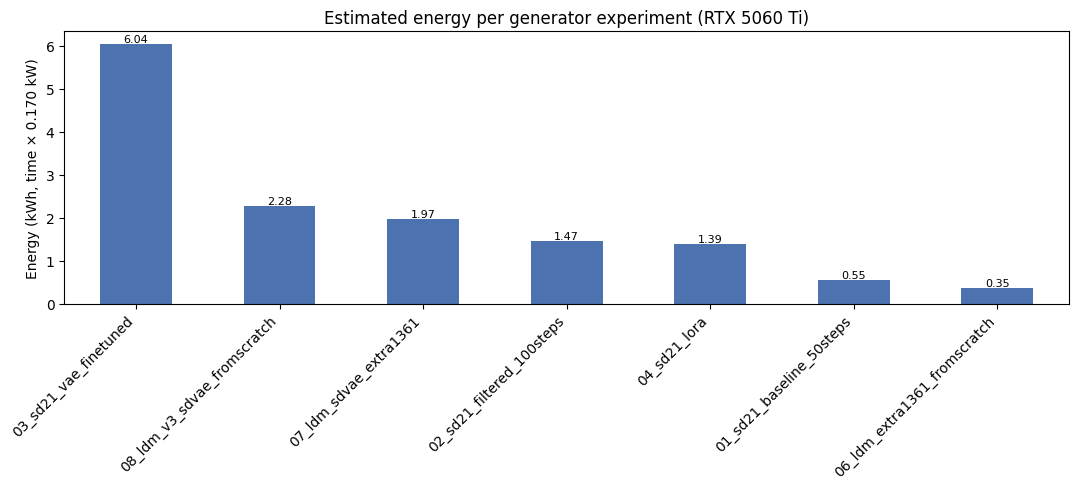

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
totals['energy_kwh'].plot.bar(ax=ax, color='#4C72B0')
ax.set_ylabel('Energy (kWh, time × 0.170 kW)'); ax.set_xlabel('')
ax.set_title('Estimated energy per generator experiment (RTX 5060 Ti)')
for i, v in enumerate(totals['energy_kwh']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_total.png', dpi=110)


## 3. Decompose the estimate by computational phase

The stacked view applies the same time-to-energy conversion separately to training, generation,
filtering, and validation. It shows which phases dominate each canonical workflow without combining
failed attempts or reused artifacts. Because G06 reuses G05 training state, its contribution should
be interpreted as the cost of extending a generation pool, not as an independent model-training
footprint.

phase,generator_training,generation,filtering,validation
generator,,,,
03_sd21_vae_finetuned,2.596,2.006,0.000,1.437
08_ldm_v3_sdvae_fromscratch,1.171,0.982,0.098,0.030
07_ldm_sdvae_extra1361,1.135,0.820,0.009,0.008
02_sd21_filtered_100steps,0.000,0.469,0.996,0.000
04_sd21_lora,0.836,0.403,0.000,0.151
01_sd21_baseline_50steps,0.367,0.158,0.000,0.022
06_ldm_extra1361_fromscratch,0.000,0.227,0.071,0.056


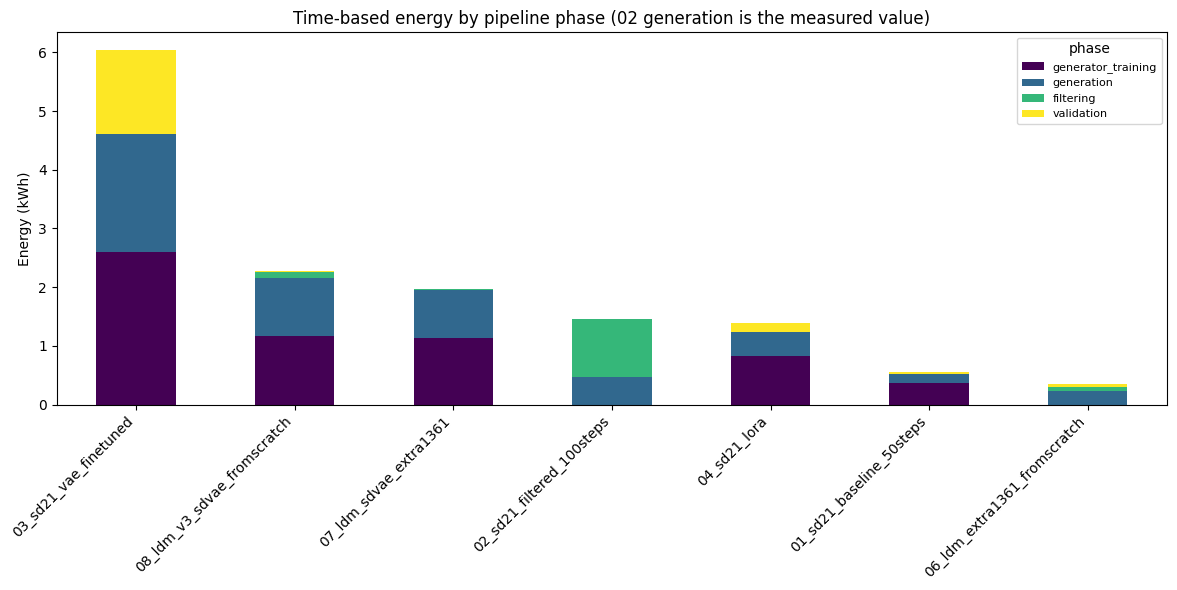

In [4]:
energy_by_phase = (by_phase * POWER_KW).loc[totals.index]
fig, ax = plt.subplots(figsize=(12, 6))
energy_by_phase.plot.bar(stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('Energy (kWh)'); ax.set_xlabel('')
ax.set_title('Time-based energy by pipeline phase (02 generation is the measured value)')
ax.legend(title='phase', fontsize=8); ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_by_phase.png', dpi=110)
energy_by_phase.round(3)

## 4. Normalize generation cost to the canonical 1,361-image pool

Generation hours and energy are converted to a common 1,361-image output target. G02 uses its
controlled 100-image, 100-step timing measurement and a linear extrapolation because the historical
event mixed generation with filtering; other candidates use compatible canonical generation events.
The normalization enables a like-sized comparison but assumes approximately constant throughput and
therefore does not capture startup, batching, or multi-GPU scaling nonlinearities.

,generation_hours,generation_kwh
generator,,
03_sd21_vae_finetuned,11.801,2.006
08_ldm_v3_sdvae_fromscratch,5.779,0.982
07_ldm_sdvae_extra1361,4.825,0.820
02_sd21_filtered_100steps,2.761,0.469
04_sd21_lora,2.371,0.403
01_sd21_baseline_50steps,0.931,0.158
06_ldm_extra1361_fromscratch,1.338,0.227


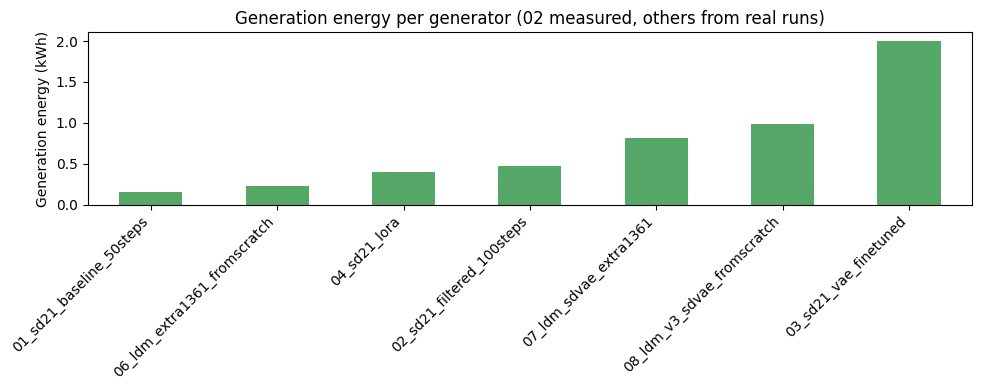

In [5]:
gen_hours = by_phase['generation'].copy()
gen_energy_pool = gen_hours * POWER_KW
table = pd.DataFrame({'generation_hours': gen_hours, 'generation_kwh': gen_energy_pool}).loc[totals.index]
fig, ax = plt.subplots(figsize=(10, 4))
table['generation_kwh'].sort_values().plot.bar(ax=ax, color='#55A868')
ax.set_ylabel('Generation energy (kWh)'); ax.set_xlabel('')
ax.set_title('Generation energy per generator (02 measured, others from real runs)')
ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generation_efficiency.png', dpi=110)
table.round(3)

## Interpretation and reporting boundaries

- Energy is estimated as canonical wall-clock hours × 0.170 kW for one measured RTX 5060 Ti operating
  context; the notebook does not claim direct electricity or carbon measurement.
- Events of 60 s or less and exact duplicate records are excluded by the canonical registry policy;
  genuine resumed segments remain additive, while failed and noncanonical development work is absent.
- G02 generation is extrapolated from a controlled 100-image timing sample, and the associated
  linear-throughput assumption is an explicit source of uncertainty.
- G05 lacks a reliable canonical energy record and is omitted from totals; G06 reuses G05's model and
  represents only the additional-pool ablation. Its historical training-labelled events are therefore
  excluded rather than misreported as a second model-training footprint. Results compare documented
  canonical workflows, not the complete energy history of the research project.